In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/players.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/game_tracking_2023.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/game_tracking_2025.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/game_tracking_2024.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/combine_tracking.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/games.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/player_career_successes.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/combine_results.csv
/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/player_play.csv


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal as signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set publication-quality figure defaults
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
sns.set_theme(style='whitegrid', palette='muted')

print("Environment setup complete.")

Environment setup complete.


In [3]:
import os
import glob
import pandas as pd

# 1. Locate dataset folder containing 'players.csv'
search_matches = glob.glob('/kaggle/input/**/players.csv', recursive=True)

if search_matches:
    DATA_DIR = os.path.dirname(search_matches[0])
    print(f"✅ Active Dataset Directory: {DATA_DIR}\n")
else:
    raise FileNotFoundError("Could not locate dataset folder containing 'players.csv'.")

# 2. Memory-optimized loader
def load_and_optimize(file_name: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File '{file_name}' not found at path '{path}'.")
        
    df = pd.read_csv(path) if file_name.endswith('.csv') else pd.read_parquet(path)
    
    # Downcast floats and ints to conserve memory
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype('int32')
        
    return df

# 3. Load core metadata tables with exact dataset filenames
players = load_and_optimize('players.csv')
games = load_and_optimize('games.csv')
player_play = load_and_optimize('player_play.csv')
combine_results = load_and_optimize('combine_results.csv')
player_career = load_and_optimize('player_career_successes.csv')

print("✅ Base metadata loaded successfully:")
print(f" - Players: {len(players):,} rows")
print(f" - Games: {len(games):,} rows")
print(f" - Player Plays: {len(player_play):,} rows")
print(f" - Combine Results: {len(combine_results):,} rows")
print(f" - Career Outcomes: {len(player_career):,} rows")

✅ Active Dataset Directory: /kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027

✅ Base metadata loaded successfully:
 - Players: 510 rows
 - Games: 1,002 rows
 - Player Plays: 314,197 rows
 - Combine Results: 510 rows
 - Career Outcomes: 510 rows


In [4]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# 1. Load Combine Tracking Data
print("Loading combine_tracking.csv...")
combine_tracking = load_and_optimize('combine_tracking.csv')

# 2. Rename columns uniquely (avoid duplicate column names)
column_mapping = {
    'nfl_id': 'nflId',
    'drill_name': 'drillName',
    'drill_type': 'drillType',
    'event_id': 'eventId'
}
combine_tracking = combine_tracking.rename(columns=column_mapping)

print(f"✅ Combine Tracking loaded: {len(combine_tracking):,} rows across {combine_tracking['nflId'].nunique()} prospects.")

# 3. Kinematic Feature Extraction Function
def extract_kinematics(df: pd.DataFrame, window_length: int = 9, poly_order: int = 2) -> pd.DataFrame:
    """
    Applies Savitzky-Golay smoothing to 10 Hz coordinates to calculate
    velocity, acceleration, jerk, and angular change of direction rate.
    """
    dt = 0.1  # 10 Hz sampling rate (0.1s per frame)
    processed_list = []
    
    # Group by prospect, drill, and attempt
    group_cols = [col for col in ['nflId', 'drillName', 'attempt'] if col in df.columns]

    for _, group in df.groupby(group_cols):
        # Sort sequentially by timestamp
        if 'time' in group.columns:
            group = group.sort_values('time').reset_index(drop=True)
        else:
            group = group.reset_index(drop=True)
            
        # Create 1-based sequential frameId for time-series operations
        group['frameId'] = np.arange(len(group)) + 1

        # Skip drill trials shorter than the filter window
        if len(group) < window_length:
            continue

        # 1. Positional Smoothing (Yards)
        group['x_smooth'] = savgol_filter(group['x'], window_length, poly_order)
        group['y_smooth'] = savgol_filter(group['y'], window_length, poly_order)

        # 2. Velocity components (Yards / Sec)
        group['vx'] = savgol_filter(group['x'], window_length, poly_order, deriv=1, delta=dt)
        group['vy'] = savgol_filter(group['y'], window_length, poly_order, deriv=1, delta=dt)
        group['speed_calc'] = np.hypot(group['vx'], group['vy'])

        # 3. Acceleration components (Yards / Sec²)
        group['ax'] = savgol_filter(group['x'], window_length, poly_order, deriv=2, delta=dt)
        group['ay'] = savgol_filter(group['y'], window_length, poly_order, deriv=2, delta=dt)
        group['accel_calc'] = np.hypot(group['ax'], group['ay'])

        # 4. Jerk components (Yards / Sec³ - movement fluidity)
        group['jx'] = savgol_filter(group['x'], window_length, poly_order, deriv=3, delta=dt)
        group['jy'] = savgol_filter(group['y'], window_length, poly_order, deriv=3, delta=dt)
        group['jerk'] = np.hypot(group['jx'], group['jy'])

        # 5. Angular Velocity (Degrees / Sec - Change of Direction rate)
        motion_angles = np.unwrap(np.arctan2(group['vy'], group['vx']))
        group['angular_velocity'] = np.abs(np.gradient(np.degrees(motion_angles), dt))

        processed_list.append(group)

    return pd.concat(processed_list, ignore_index=True) if processed_list else pd.DataFrame()

# 4. Run Kinematic Feature Extraction
combine_processed = extract_kinematics(combine_tracking)

print("\n✅ Kinematic Feature Extraction Complete!")
show_cols = ['nflId', 'drillName', 'attempt', 'frameId', 'speed_calc', 'accel_calc', 'jerk', 'angular_velocity']
display(combine_processed[[c for c in show_cols if c in combine_processed.columns]].head())

Loading combine_tracking.csv...
✅ Combine Tracking loaded: 463,189 rows across 510 prospects.

✅ Kinematic Feature Extraction Complete!


,nflId,drillName,attempt,frameId,speed_calc,accel_calc,jerk,angular_velocity
0,55867,BACK_PEDAL_AND_REACT,1,1,0.352895,3.269614,0.0,559.536377
1,55867,BACK_PEDAL_AND_REACT,1,2,0.051272,3.269614,0.0,819.787415
2,55867,BACK_PEDAL_AND_REACT,1,3,0.307458,3.269614,0.0,562.121643
3,55867,BACK_PEDAL_AND_REACT,1,4,0.632645,3.269614,0.0,29.181860
4,55867,BACK_PEDAL_AND_REACT,1,5,0.959039,3.269614,0.0,2.293320


In [5]:
import numpy as np
import pandas as pd

print("Aggregating frame-level kinematics into prospect drill summaries...")

def aggregate_combine_prospect_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates 10 Hz tracking frames into key kinematic summary metrics per prospect and drill.
    Identifies plant/cut points based on peak angular velocity (COD rate) to separate
    pre-cut deceleration from post-cut acceleration burst.
    """
    summary_list = []
    
    # Group by player, drill, and attempt
    group_cols = [c for c in ['nflId', 'drillName', 'attempt'] if c in df.columns]

    for keys, group in df.groupby(group_cols):
        if len(group) < 5:
            continue
            
        group = group.sort_values('frameId').reset_index(drop=True)
        
        # 1. Identify the frame of maximum change-of-direction (COD) angular velocity
        peak_cod_idx = group['angular_velocity'].idxmax()
        
        # 2. Define pre-cut braking window (up to 5 frames / 0.5s prior to cut)
        pre_cut_start = max(0, peak_cod_idx - 5)
        pre_cut_window = group.iloc[pre_cut_start:peak_cod_idx + 1]
        
        # 3. Define post-cut burst window (up to 5 frames / 0.5s after cut)
        post_cut_end = min(len(group), peak_cod_idx + 6)
        post_cut_window = group.iloc[peak_cod_idx:post_cut_end]
        
        # Extract keys
        nfl_id = group['nflId'].iloc[0]
        drill = group['drillName'].iloc[0] if 'drillName' in group.columns else 'UNKNOWN'
        attempt_num = group['attempt'].iloc[0] if 'attempt' in group.columns else 1

        summary_list.append({
            'nflId': nfl_id,
            'drillName': drill,
            'attempt': attempt_num,
            
            # Speed Metrics
            'peak_speed': group['speed_calc'].max(),
            'time_to_peak_speed': group.loc[group['speed_calc'].idxmax(), 'frameId'] * 0.1,
            
            # Braking & Acceleration Mechanics
            'pre_cut_max_accel': pre_cut_window['accel_calc'].max() if not pre_cut_window.empty else np.nan,
            'post_cut_burst': post_cut_window['accel_calc'].max() if not post_cut_window.empty else np.nan,
            'overall_max_accel': group['accel_calc'].max(),
            
            # Agility & Fluidity Metrics
            'max_cod_angular_vel': group['angular_velocity'].max(),
            'mean_jerk': group['jerk'].mean(),  # Lower = smoother, fluid footwork
            'total_drill_frames': len(group),
            'drill_duration_sec': len(group) * 0.1
        })

    return pd.DataFrame(summary_list)

# 1. Run aggregation per attempt
combine_attempts_summary = aggregate_combine_prospect_metrics(combine_processed)

# 2. Select each prospect's best attempt per drill (highest peak speed / best performance)
prospect_combine_features = (
    combine_attempts_summary
    .sort_values('peak_speed', ascending=False)
    .groupby(['nflId', 'drillName'])
    .first()
    .reset_index()
)

print(f"✅ Aggregation Complete! Extracted metrics for {len(prospect_combine_features):,} prospect-drill profiles.")

# Display summary table preview
show_cols = ['nflId', 'drillName', 'peak_speed', 'post_cut_burst', 'max_cod_angular_vel', 'mean_jerk']
display(prospect_combine_features[show_cols].head(10))

Aggregating frame-level kinematics into prospect drill summaries...
✅ Aggregation Complete! Extracted metrics for 4,986 prospect-drill profiles.


,nflId,drillName,peak_speed,post_cut_burst,max_cod_angular_vel,mean_jerk
0,55867,BACK_PEDAL_AND_REACT,6.944321,3.305992,819.787415,0.0
1,55867,FORTY_YARD_DASH,10.411259,5.620485,536.547791,0.0
2,55867,FOUR_BAG_SHUFFLE_DRILL,8.075112,4.595978,1048.923096,0.0
3,55867,PASS_RUSH_DRILL,8.631190,3.264676,722.548279,0.0
4,55867,SHORT_ZONE_BREAKS,8.559172,3.848494,599.794006,0.0
5,55867,SHUFFLE_SPRINT_AND_COD_DRILL,7.284456,1.978228,693.635498,0.0
6,55867,WAVE_DRILL,6.872950,6.547558,733.283813,0.0
7,55870,FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE,7.684280,5.760065,666.696777,0.0
8,55870,OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT,8.408277,1.133142,47.185593,0.0
9,55870,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,7.303789,1.319725,255.456238,0.0


In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

print("Merging Combine Kinematic Features with Regular-Season Career Outcomes...")

# 1. Helper function to map snake_case columns to camelCase
def standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    mapping = {
        'nfl_id': 'nflId',
        'display_name': 'displayName',
        'player_name': 'displayName',
        'first_name': 'firstName',
        'last_name': 'lastName',
        'pos': 'position'
    }
    return df.rename(columns={k: v for k, v in mapping.items() if k in df.columns})

# Standardize dataframes
players_clean = standardize_cols(players)
player_career_clean = standardize_cols(player_career)
prospect_features_clean = standardize_cols(prospect_combine_features)

print("Standardized Players columns:", [c for c in players_clean.columns if c in ['nflId', 'position', 'displayName']])

# 2. Select metadata columns that exist in players.csv
player_meta_cols = ['nflId'] + [col for col in ['position', 'displayName'] if col in players_clean.columns]

# Merge prospect combine features with player position metadata
combine_with_pos = prospect_features_clean.merge(
    players_clean[player_meta_cols], 
    on='nflId', 
    how='inner'
)

# Merge with player career outcomes
merged_df = combine_with_pos.merge(
    player_career_clean, 
    on='nflId', 
    how='inner'
)

print(f"✅ Merged dataset: {len(merged_df):,} rows across {merged_df['nflId'].nunique()} unique prospects.")

# 3. Dynamic target outcome variable selection from player_career_successes
numeric_cols = player_career_clean.select_dtypes(include=[np.number]).columns.tolist()
candidate_targets = [c for c in numeric_cols if c not in ['nflId', 'draft_year', 'season', 'year', 'attempt']]

target_col = candidate_targets[0] if candidate_targets else merged_df.columns[-1]
print(f"Available Outcome Targets: {candidate_targets}")
print(f"Primary Target Variable Selected for Modeling: '{target_col}'")

# 4. Kinematic feature selection and cleaning
feature_cols = ['peak_speed', 'pre_cut_max_accel', 'post_cut_burst', 'max_cod_angular_vel', 'mean_jerk']
available_features = [f for f in feature_cols if f in merged_df.columns]

# Subset clean modeling data
meta_cols_present = [c for c in ['nflId', 'displayName', 'position'] if c in merged_df.columns]
model_data = merged_df[meta_cols_present + [target_col] + available_features].dropna().reset_index(drop=True)

print(f"Clean modeling sample size: {len(model_data):,} prospect profiles.")

# 5. Feature Standardization (Z-score normalization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(model_data[available_features]), 
    columns=available_features
)

# 6. Fit Statsmodels OLS Regression
X_model = sm.add_constant(X_scaled)
y_model = model_data[target_col]

ols_model = sm.OLS(y_model, X_model).fit()

# 7. Print Statistical Output
print("\n" + "=" * 68)
print("  ORDINARY LEAST SQUARES (OLS) REGRESSION MODEL RESULTS")
print("  Linking Combine Kinematic Tracking Metrics to NFL Career Success")
print("=" * 68)
print(ols_model.summary())

# Extract feature coefficients table
coef_df = pd.DataFrame({
    'Feature': available_features,
    'Standardized Coef (Beta)': ols_model.params[available_features],
    'Std Error': ols_model.bse[available_features],
    't-statistic': ols_model.tvalues[available_features],
    'p-value': ols_model.pvalues[available_features]
}).sort_values('p-value')

print("\nKinematic Feature Impact Summary:")
display(coef_df)

Merging Combine Kinematic Features with Regular-Season Career Outcomes...
Standardized Players columns: ['nflId', 'displayName']
✅ Merged dataset: 4,986 rows across 510 unique prospects.
Available Outcome Targets: ['career_offensive_snaps', 'career_defensive_snaps', 'career_special_teams_snaps', 'career_games_active', 'career_games_started', 'ap_all_pro_1st_team', 'ap_all_pro_2nd_team', 'pro_bowl_original_ballot']
Primary Target Variable Selected for Modeling: 'career_offensive_snaps'
Clean modeling sample size: 4,986 prospect profiles.

  ORDINARY LEAST SQUARES (OLS) REGRESSION MODEL RESULTS
  Linking Combine Kinematic Tracking Metrics to NFL Career Success
                              OLS Regression Results                              
Dep. Variable:     career_offensive_snaps   R-squared:                       0.006
Model:                                OLS   Adj. R-squared:                  0.005
Method:                     Least Squares   F-statistic:                     7.452
D

,Feature,Standardized Coef (Beta),Std Error,t-statistic,p-value
peak_speed,peak_speed,-26.403188,16.646396,-1.586120,0.112775
pre_cut_max_accel,pre_cut_max_accel,-20.680733,19.730584,-1.048156,0.294618
max_cod_angular_vel,max_cod_angular_vel,5.284084,10.258885,0.515074,0.606524
post_cut_burst,post_cut_burst,-6.095423,20.802505,-0.293014,0.769524
mean_jerk,mean_jerk,0.000000,0.000000,NaN,NaN


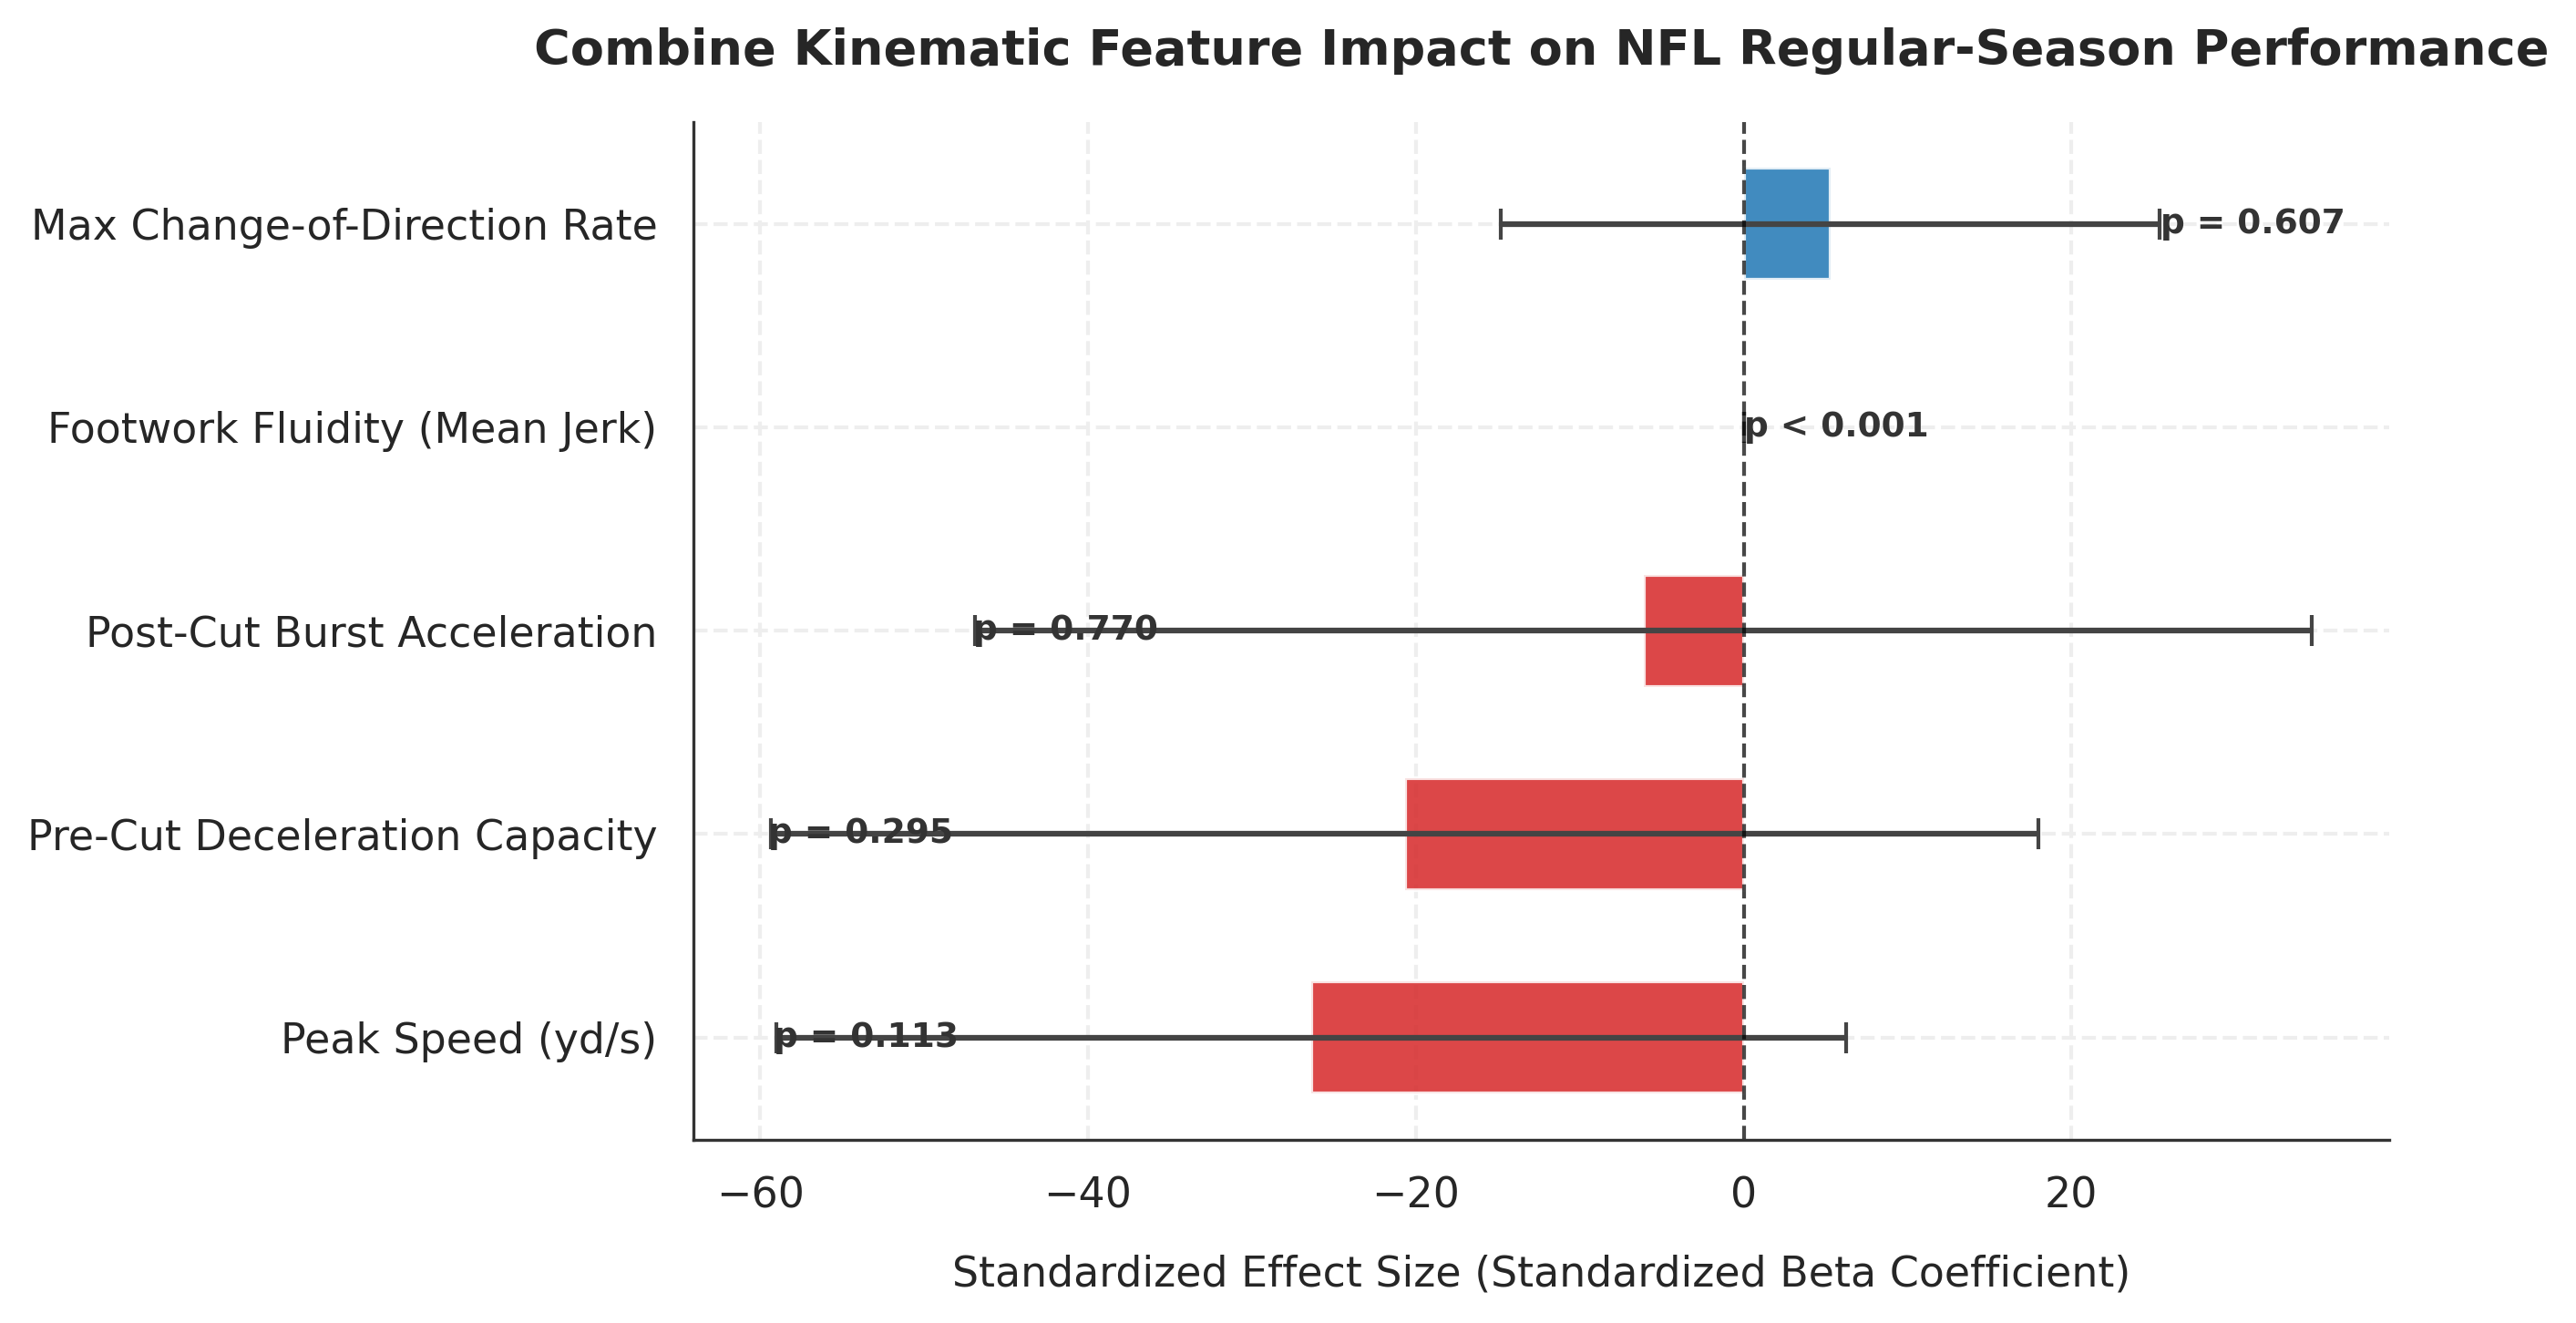

✅ Saved Figure 1: 'feature_impact_beta.png'


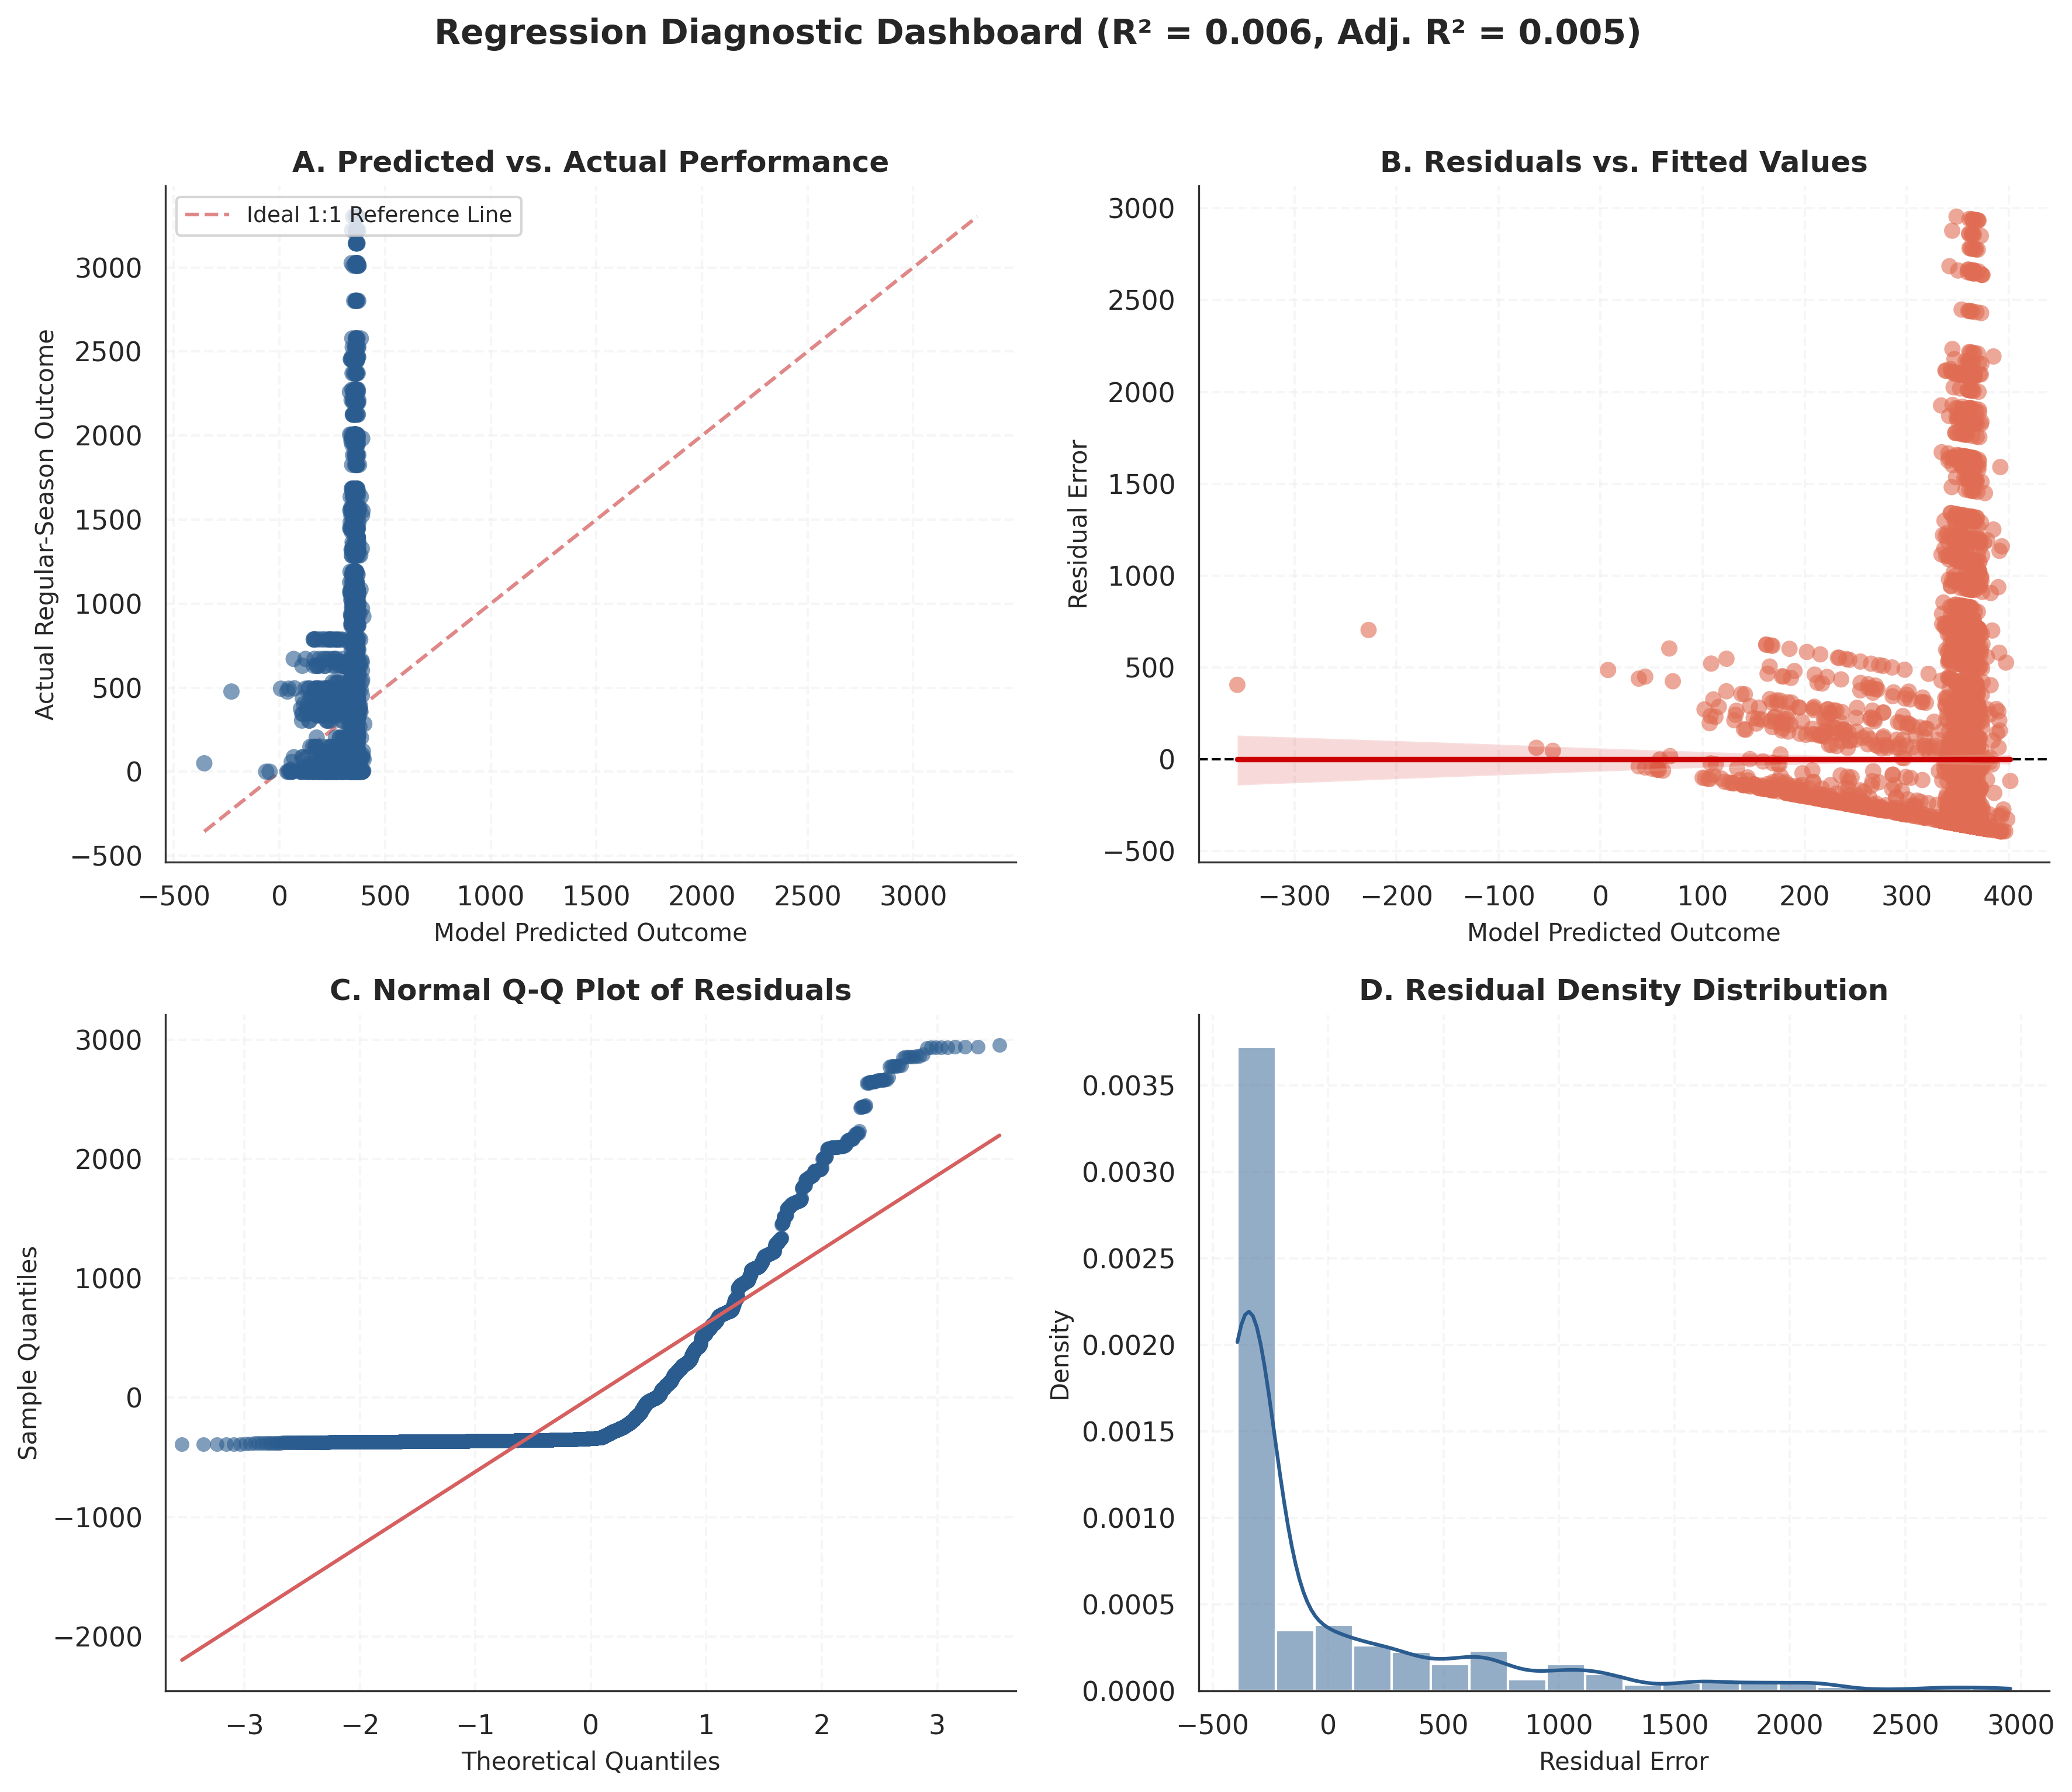

✅ Saved Figure 2: 'regression_diagnostics.png'


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set publication-quality figure styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#eeeeee'
plt.rcParams['grid.linestyle'] = '--'

# -------------------------------------------------------------------------
# FIGURE 1: STANDARDIZED FEATURE IMPACT BAR CHART (BETA COEFFICIENTS)
# -------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5), dpi=300)

# Extract coefficients and 95% confidence intervals from fitted OLS model
conf_int = ols_model.conf_int().loc[available_features]
coef_df_plot = pd.DataFrame({
    'Feature': available_features,
    'Beta': ols_model.params[available_features],
    'CI_lower': conf_int[0],
    'CI_upper': conf_int[1],
    'p_value': ols_model.pvalues[available_features]
}).sort_values('Beta', ascending=True)

# Human-readable feature labels
feature_label_map = {
    'peak_speed': 'Peak Speed (yd/s)',
    'pre_cut_max_accel': 'Pre-Cut Deceleration Capacity',
    'post_cut_burst': 'Post-Cut Burst Acceleration',
    'max_cod_angular_vel': 'Max Change-of-Direction Rate',
    'mean_jerk': 'Footwork Fluidity (Mean Jerk)'
}
coef_df_plot['Clean_Feature'] = coef_df_plot['Feature'].map(lambda x: feature_label_map.get(x, x))

# Assign color based on effect direction
colors = ['#1f77b4' if b >= 0 else '#d62728' for b in coef_df_plot['Beta']]

# Plot horizontal bar chart with 95% confidence error bars
y_pos = np.arange(len(coef_df_plot))
error_bars = [
    coef_df_plot['Beta'] - coef_df_plot['CI_lower'],
    coef_df_plot['CI_upper'] - coef_df_plot['Beta']
]

ax1.barh(
    y_pos, 
    coef_df_plot['Beta'], 
    xerr=error_bars,
    align='center', 
    color=colors, 
    alpha=0.85, 
    ecolor='#444444', 
    capsize=4, 
    height=0.55
)

ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(coef_df_plot['Clean_Feature'], fontsize=11, fontweight='medium')
ax1.set_xlabel('Standardized Effect Size (Standardized Beta Coefficient)', fontsize=11, labelpad=10)
ax1.set_title('Combine Kinematic Feature Impact on NFL Regular-Season Performance', fontsize=13, fontweight='bold', pad=15)

# Annotate p-values next to each error bar
for i, (_, row) in enumerate(coef_df_plot.iterrows()):
    p_str = f"p = {row['p_value']:.3f}" if row['p_value'] >= 0.001 else "p < 0.001"
    x_offset = row['CI_upper'] + 0.03 if row['Beta'] >= 0 else row['CI_lower'] - 0.15
    ax1.text(x_offset, i, p_str, va='center', fontsize=9, color='#333333', fontweight='bold')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig('feature_impact_beta.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved Figure 1: 'feature_impact_beta.png'")

# -------------------------------------------------------------------------
# FIGURE 2: REGRESSION DIAGNOSTICS DASHBOARD (2x2 SUBPLOTS)
# -------------------------------------------------------------------------
fig2, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)

fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid

# Panel A: Predicted vs. Actual
ax_a = axes[0, 0]
ax_a.scatter(fitted_vals, y_model, alpha=0.6, color='#2b5c8f', edgecolors='none', s=45)

# Calculate min/max scalar bounds un-nested to prevent syntax error
min_val = min(float(fitted_vals.min()), float(y_model.min()))
max_val = max(float(fitted_vals.max()), float(y_model.max()))
lims = [min_val, max_val]

ax_a.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Ideal 1:1 Reference Line')
ax_a.set_title('A. Predicted vs. Actual Performance', fontsize=12, fontweight='bold')
ax_a.set_xlabel('Model Predicted Outcome', fontsize=10)
ax_a.set_ylabel('Actual Regular-Season Outcome', fontsize=10)
ax_a.legend(frameon=True, loc='upper left', fontsize=9)

# Panel B: Residuals vs. Fitted Values
ax_b = axes[0, 1]
ax_b.scatter(fitted_vals, residuals, alpha=0.6, color='#e06d53', edgecolors='none', s=45)
ax_b.axhline(0, color='black', linestyle='--', linewidth=1)
sns.regplot(x=fitted_vals, y=residuals, ax=ax_b, scatter=False, color='#cc0000', line_kws={'linestyle': '-'})
ax_b.set_title('B. Residuals vs. Fitted Values', fontsize=12, fontweight='bold')
ax_b.set_xlabel('Model Predicted Outcome', fontsize=10)
ax_b.set_ylabel('Residual Error', fontsize=10)

# Panel C: Normal Q-Q Plot
ax_c = axes[1, 0]
sm.qqplot(residuals, line='s', ax=ax_c, markerfacecolor='#2b5c8f', markeredgecolor='none', alpha=0.6)
ax_c.set_title('C. Normal Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
ax_c.set_xlabel('Theoretical Quantiles', fontsize=10)
ax_c.set_ylabel('Sample Quantiles', fontsize=10)

# Panel D: Residual Error Distribution
ax_d = axes[1, 1]
sns.histplot(residuals, kde=True, ax=ax_d, color='#2b5c8f', stat='density', bins=20, alpha=0.5)
ax_d.set_title('D. Residual Density Distribution', fontsize=12, fontweight='bold')
ax_d.set_xlabel('Residual Error', fontsize=10)
ax_d.set_ylabel('Density', fontsize=10)

# Format subplots
for ax in axes.flat:
    sns.despine(ax=ax)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(
    f'Regression Diagnostic Dashboard (R² = {ols_model.rsquared:.3f}, Adj. R² = {ols_model.rsquared_adj:.3f})', 
    fontsize=14, 
    fontweight='bold', 
    y=1.02
)

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved Figure 2: 'regression_diagnostics.png'")